# Module 09 — Neural Networks from Scratch

*A brain cell made of math — built with nothing but NumPy.*

In 1943, a neurophysiologist (Warren McCulloch) and a self-taught logician (Walter Pitts) asked a wild question: could the neurons you know from biology — dendrites collecting signals, a soma summing them, an axon firing past a threshold — be captured in simple math? Their paper became the seed of every neural network since, up to and including GPT. In this module we build their idea with bare NumPy: one neuron first, then a small network that *learns*.

There is no field-collected dataset this time, and that's deliberate. We generate a synthetic benchmark called **two moons**: 400 points, 2 classes, and — crucially — only **2 features**. With 2 features, every data point fits on a flat plot and we can *draw the model's decision boundary* and watch it move as the network learns. A real expression matrix with 20,000 genes would make that impossible to see. Think of two moons as the model organism of this module: simple, controlled, and chosen to make one mechanism visible.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining what it does.

In [1]:
import numpy as np                # arrays and math (Module 01)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# Fixed colors we reuse in every plot (a colorblind-friendly palette).
palette = sns.color_palette("colorblind")
COLOR_MOON0 = palette[0]   # blue
COLOR_MOON1 = palette[1]   # orange
COLOR_ACCENT = palette[2]  # green

np.random.seed(42)   # make any randomness reproducible

## 1. A real neuron vs an artificial one

You already know the real thing better than most programmers do:

| Real neuron | Math version |
|---|---|
| dendrites receive signals through synapses | inputs `x1, x2, ...` |
| synapse strength (excitatory or inhibitory) | weight `w1, w2, ...` (positive or negative) |
| soma adds the signals up | the weighted sum `w1*x1 + w2*x2 + b` |
| firing threshold | the bias `b` (a low `b` = a hard-to-trigger neuron) |
| fires an action potential, or stays quiet | the **activation function** squashes the sum into an output |

**Where the analogy honestly breaks** — keep these in the back of your mind:

- Real neurons fire discrete spikes *in time*; ours outputs one steady number.
- Real synapses strengthen by *local* rules ("fire together, wire together"). Our network will learn from a *global* error signal passed backward — there is no strong evidence brains do that.
- A real neuron has thousands of synapses and its own chemistry; ours has a handful of numbers.

An artificial neuron is a stick figure of a neuron. Stick figures are still useful — let's draw one.

## 2. One neuron, computed by hand

Picture a sensory neuron with **two synapses**: synapse 1 is excitatory (pushes it toward firing), synapse 2 is inhibitory (pushes against). We'll *hand-pick* the weights — no learning yet — and feed it two different input signals, using nothing but plain arithmetic.

In [2]:
# Hand-picked "synapse strengths" (weights) and threshold setting (bias):
w1 = 1.0    # synapse 1: excitatory (positive weight)
w2 = -1.0   # synapse 2: inhibitory (negative weight)
b = 0.0     # bias: with b = 0 the neuron is neutral -- neither eager nor reluctant to fire

# --- Input A: strong signal at the excitatory synapse, weak at the inhibitory one
x1 = 2.0
x2 = 1.0
weighted_sum_A = w1 * x1 + w2 * x2 + b   # 1.0*2.0 + (-1.0)*1.0 + 0.0 = 1.0
print("input A: weighted sum =", weighted_sum_A)

# --- Input B: weak excitatory signal, strong inhibitory one
x1 = 0.0
x2 = 3.0
weighted_sum_B = w1 * x1 + w2 * x2 + b   # 1.0*0.0 + (-1.0)*3.0 + 0.0 = -3.0
print("input B: weighted sum =", weighted_sum_B)

input A: weighted sum = 1.0
input B: weighted sum = -3.0


A real neuron would now compare the summed input to its threshold: above it → fire an action potential, below it → silence. A hard yes/no like that turns out to be terrible for *learning* (we'll need slopes later, and a cliff has no usable slope). So instead we use a **smooth** threshold: the **sigmoid** function, which squashes any number into the range 0 to 1 — read it as *"the probability that the neuron fires."*

In [3]:
def sigmoid(z):
    # np.exp(z) is e**z (the exponential function).
    # For large positive z this returns ~1, for large negative z ~0,
    # and for z = 0 exactly 0.5 -- a smooth, S-shaped "maybe".
    return 1.0 / (1.0 + np.exp(-z))

print("input A: sum =  1.0  ->  firing probability =", round(sigmoid(weighted_sum_A), 3))
print("input B: sum = -3.0  ->  firing probability =", round(sigmoid(weighted_sum_B), 3))

input A: sum =  1.0  ->  firing probability = 0.731
input B: sum = -3.0  ->  firing probability = 0.047


Input A excites the neuron (73% "fire"), input B inhibits it (5% "fire"). That's the entire artificial neuron: **multiply, add, squash.** Everything else in this module is about wiring these together and making the weights learn themselves.

## 3. One neuron *is* logistic regression

Look again at what our neuron computes: `sigmoid(w1*x1 + w2*x2 + b)` — a weighted sum pushed through the S-curve to give a probability. That is *exactly* logistic regression from Module 06. One artificial neuron and logistic regression are the same model wearing different costumes.

Let's plot the sigmoid to fix its shape in your mind.

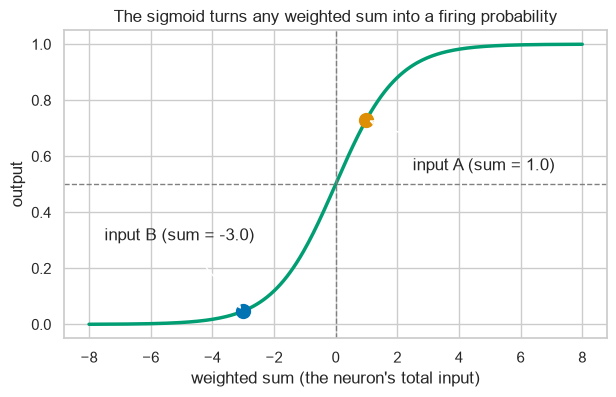

In [4]:
# 300 evenly spaced values from -8 to 8 to draw a smooth curve (Module 01's linspace).
z_values = np.linspace(-8, 8, 300)      # shape: (300,) -- 300 candidate weighted sums

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_values, sigmoid(z_values), color=COLOR_ACCENT, linewidth=2.5)

# Dashed guide lines showing the midpoint: weighted sum 0 -> probability 0.5.
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)   # horizontal line at y = 0.5
ax.axvline(0, color="gray", linestyle="--", linewidth=1)     # vertical line at x = 0

# Mark our two hand-computed inputs from section 2 on the curve.
ax.plot(1.0, sigmoid(1.0), "o", color=COLOR_MOON1, markersize=10)
ax.annotate("input A (sum = 1.0)", xy=(1.0, sigmoid(1.0)), xytext=(2.5, 0.55),
            arrowprops=dict(arrowstyle="->"))
ax.plot(-3.0, sigmoid(-3.0), "o", color=COLOR_MOON0, markersize=10)
ax.annotate("input B (sum = -3.0)", xy=(-3.0, sigmoid(-3.0)), xytext=(-7.5, 0.3),
            arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("weighted sum (the neuron's total input)")
ax.set_ylabel("output")
ax.set_title("The sigmoid turns any weighted sum into a firing probability")
plt.show()

## 4. Two moons: where a straight line fails

A single neuron draws one straight boundary line. Time to meet a dataset that laughs at straight lines.

`make_moons` (from scikit-learn) generates two crescent-shaped classes that interlock like a yin-yang — imagine two cell populations on a 2-marker flow-cytometry plot whose clouds curl around each other, so no single straight gate can separate them. The `noise` argument adds random scatter so the crescents overlap a little, like real measurements would.

In [5]:
from sklearn.datasets import make_moons   # scikit-learn's toy-data generator

# n_samples: how many points; noise: how much random scatter; random_state: reproducible
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

print("X shape:", X.shape)   # shape: (400, 2) -- 400 moons points, 2 features each
print("y shape:", y.shape)   # shape: (400,)   -- one label per point: 0 or 1
print("first 3 points:")
print(X[:3])
print("first 3 labels:", y[:3])

X shape: (400, 2)
y shape: (400,)
first 3 points:
[[-0.12524467  0.55260123]
 [ 0.68508389 -0.32331529]
 [ 0.76948753  0.60722528]]
first 3 labels: [1 1 0]


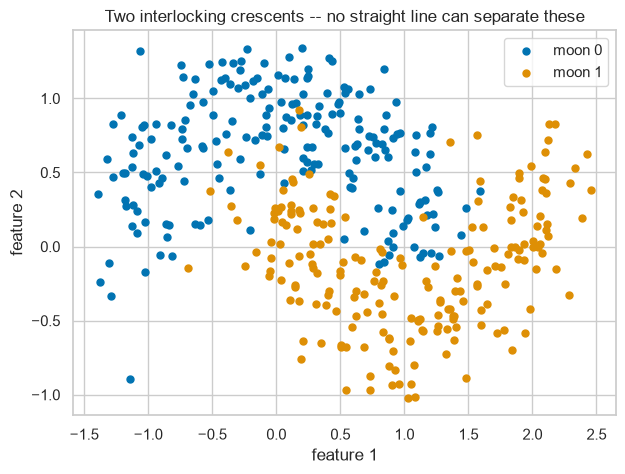

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

# Boolean masks (Module 01): y == 0 picks out the rows belonging to moon 0.
ax.scatter(X[y == 0, 0], X[y == 0, 1], color=COLOR_MOON0, s=25, label="moon 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], color=COLOR_MOON1, s=25, label="moon 1")

ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Two interlocking crescents -- no straight line can separate these")
ax.legend()
plt.show()

Now let's make the straight-line model actually try. We fit scikit-learn's `LogisticRegression` (= one artificial neuron, as we just saw) and draw its **decision boundary**: the line where the model switches from predicting moon 0 to predicting moon 1.

To draw a boundary we use a standard trick you'll reuse forever: cover the whole plot area with a fine grid of points, ask the model to classify *every* grid point, and color the background by the answer.

In [7]:
from sklearn.linear_model import LogisticRegression

line_model = LogisticRegression()   # one neuron, fitted the scikit-learn way
line_model.fit(X, y)                # learn the best straight line for this data

# .score returns accuracy: the fraction of the 400 points classified correctly.
line_accuracy = line_model.score(X, y)
print("straight-line accuracy:", line_accuracy)

straight-line accuracy: 0.8425


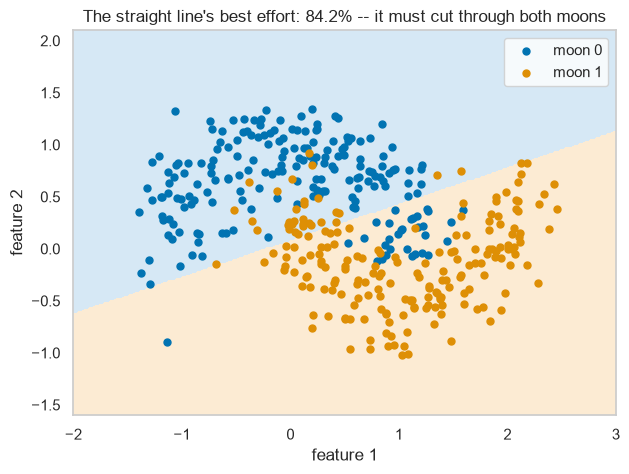

In [8]:
# --- the background-coloring trick, step by step ---
# np.meshgrid takes 200 x-values and 200 y-values and builds a 200x200 grid
# from every combination -- like the wells of a (very fine) microtiter plate.
grid_x, grid_y = np.meshgrid(np.linspace(-2.0, 3.0, 200),    # shape: (200, 200)
                             np.linspace(-1.6, 2.1, 200))    # shape: (200, 200)

# .ravel() flattens a 2-D array into 1-D (shape (40000,)), and np.column_stack
# glues the two flat arrays side by side into 40,000 (x, y) points.
grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # shape: (40000, 2)

# Classify every grid point, then reshape the 40,000 answers back into the 200x200 grid.
grid_predictions = line_model.predict(grid_points).reshape(grid_x.shape)  # shape: (200, 200)

fig, ax = plt.subplots(figsize=(7, 5))
# contourf colors the background by predicted class (light blue vs light orange).
ax.contourf(grid_x, grid_y, grid_predictions, levels=[-0.5, 0.5, 1.5],
            colors=["#D6E8F5", "#FCEBD3"])
ax.scatter(X[y == 0, 0], X[y == 0, 1], color=COLOR_MOON0, s=25, label="moon 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], color=COLOR_MOON1, s=25, label="moon 1")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("The straight line's best effort: " + str(round(line_accuracy * 100, 1))
             + "% -- it must cut through both moons")
ax.legend()
plt.show()

About 84% is this model's ceiling — not because it was fitted badly, but because its boundary *is a straight line* and the data isn't straight. The tips of each crescent are stranded on the wrong side. We need a model whose boundary can **bend**.

## 5. Activation functions — and why depth needs them

The obvious fix: stack neurons in layers, so the output of one layer feeds the next. But there's a trap. If each layer only computes weighted sums (no squashing in between), the stack **collapses back into a single straight-line model** — combining linear steps gives another linear step, the way mixing two clear solutions gives you... a clear solution.

Here's the trap, shown numerically. `@` is NumPy's matrix-multiply operator: it applies a whole layer of weighted sums at once (each column of the weight matrix holds one neuron's weights).

In [9]:
# A tiny batch of 4 data points with 2 features each.
X_tiny = np.array([[1.0, 2.0],
                   [3.0, 1.0],
                   [0.0, 4.0],
                   [2.0, 2.0]])          # shape: (4, 2) -- 4 points, 2 features

# "Layer 1": weights for 3 neurons.  "Layer 2": weights combining those 3 into 1.
M1 = np.array([[1.0, 2.0, 0.0],
               [0.0, 1.0, 3.0]])         # shape: (2, 3) -- 2 inputs -> 3 neurons
M2 = np.array([[1.0],
               [2.0],
               [1.0]])                   # shape: (3, 1) -- 3 neurons -> 1 output

# Route the data through layer 1 THEN layer 2 (no squashing in between):
two_steps = (X_tiny @ M1) @ M2           # shape: (4, 1)

# Now pre-multiply the two weight matrices into ONE matrix, and use it directly:
M_combined = M1 @ M2                     # shape: (2, 1) -- one straight-line model!
one_step = X_tiny @ M_combined           # shape: (4, 1)

print("two layers, then combined into one:")
print(np.column_stack([two_steps, one_step]))   # side by side -- identical columns
# np.allclose asks: are all values equal (allowing rounding error)?
print("identical?", np.allclose(two_steps, one_step))

two layers, then combined into one:
[[15. 15.]
 [20. 20.]
 [20. 20.]
 [20. 20.]]
identical? True


Two linear layers = one linear layer. Depth bought us *nothing*. The cure is to put a **nonlinear activation function** between the layers — a mathematical firing threshold that *bends* the signal so the collapse can't happen. Three classics:

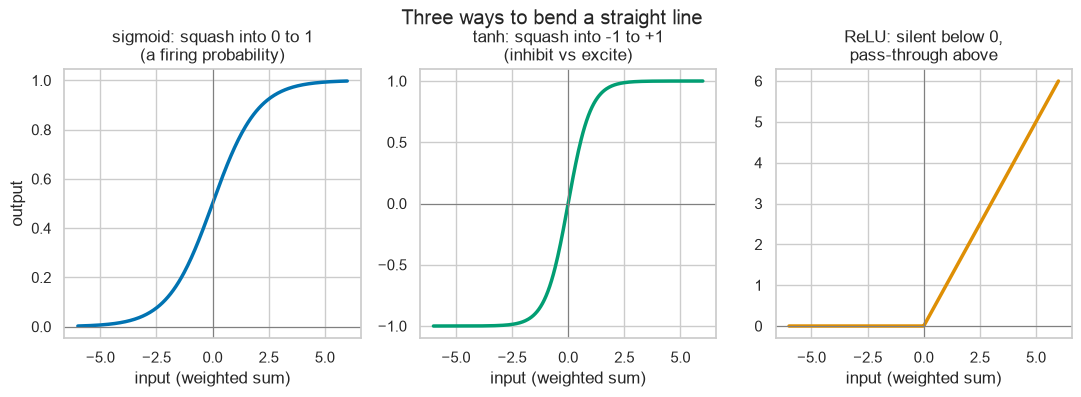

In [10]:
z = np.linspace(-6, 6, 300)   # shape: (300,) -- inputs to feed each activation

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))   # axes is a row of 3 subplots

axes[0].plot(z, sigmoid(z), color=COLOR_MOON0, linewidth=2.5)
axes[0].set_title("sigmoid: squash into 0 to 1\n(a firing probability)")

# np.tanh squashes into -1..+1, centered on 0 (think inhibit vs excite).
axes[1].plot(z, np.tanh(z), color=COLOR_ACCENT, linewidth=2.5)
axes[1].set_title("tanh: squash into -1 to +1\n(inhibit vs excite)")

# np.maximum(0, z) compares 0 with each value and keeps the larger:
# negative inputs become 0 (neuron silent), positive pass through unchanged.
axes[2].plot(z, np.maximum(0, z), color=COLOR_MOON1, linewidth=2.5)
axes[2].set_title("ReLU: silent below 0,\npass-through above")

for ax in axes:                       # same guide lines on all three panels
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("input (weighted sum)")
axes[0].set_ylabel("output")
fig.suptitle("Three ways to bend a straight line", y=1.05)
plt.show()

With a bend between the layers, the network becomes a **committee of straight-line questions**: each hidden neuron asks "are we above *my* line?", the activation bends its answer into a soft yes/no, and the output neuron combines the committee's votes into a *curved* boundary.

We'll use **tanh** for our hidden layer (its symmetric −1 to +1 output — inhibit vs excite — trains smoothly here) and **sigmoid** for the output (we want a probability).

## 6. Loss: measuring surprise

Before a network can learn, it needs a report card: one number saying *how wrong* its predictions are. That number is called the **loss** (small = good). Learning will simply mean: adjust weights to make the loss shrink.

For yes/no problems the standard loss is **binary cross-entropy**, and the best way to read it is as **surprise**:

- The model says "90% moon 1" and it *is* moon 1 → mild surprise, tiny penalty.
- The model says "99% moon 1" and it's moon 0 → you should be *shocked* — huge penalty.

Mathematically the penalty for a single point is `-log(probability the model gave the true class)`, and the loss is the average penalty over all points. Watch how the penalty explodes as the model gets confidently wrong:

*(Why not mean squared error, like in regression? MSE would work, but cross-entropy is the natural partner of the sigmoid: it punishes confident wrongness brutally — which is what we want from a classifier — and, as a bonus, it makes the learning signal in section 8 beautifully simple: just `prediction - truth`.)*

In [11]:
# Penalty = -log(probability assigned to the CORRECT answer).
# np.log is the natural logarithm; -log(1.0) = 0 (no surprise), -log(0.01) is huge.
probabilities_given_to_truth = [0.99, 0.9, 0.5, 0.1, 0.01]

for p in probabilities_given_to_truth:
    penalty = -np.log(p)
    print("model gave the true class probability", p,
          " -> surprise penalty:", round(penalty, 2))

model gave the true class probability 0.99  -> surprise penalty: 0.01
model gave the true class probability 0.9  -> surprise penalty: 0.11
model gave the true class probability 0.5  -> surprise penalty: 0.69
model gave the true class probability 0.1  -> surprise penalty: 2.3
model gave the true class probability 0.01  -> surprise penalty: 4.61


In [12]:
def bce_loss(predictions, targets):
    # predictions: the model's firing probabilities   shape: (n, 1)
    # targets: the true labels, 0.0 or 1.0            shape: (n, 1)
    # np.clip pins values into [1e-10, 1 - 1e-10] so we never take log(0),
    # which would be -infinity and wreck the math.
    p = np.clip(predictions, 1e-10, 1 - 1e-10)
    # If the target is 1 the first term counts the surprise; if 0, the second does.
    per_point_surprise = -(targets * np.log(p) + (1 - targets) * np.log(1 - p))
    return per_point_surprise.mean()   # average surprise over all points

# Sanity checks on tiny hand-made examples:
confident_right = np.array([[0.99]])   # said 99% "class 1", truth IS 1
confident_wrong = np.array([[0.99]])   # said 99% "class 1"...
truth_one = np.array([[1.0]])
truth_zero = np.array([[0.0]])
print("confidently right:", round(bce_loss(confident_right, truth_one), 3))
print("confidently WRONG:", round(bce_loss(confident_wrong, truth_zero), 3))

confidently right: 0.01
confidently WRONG: 4.605


## 7. Gradient descent: walking downhill in fog

We have a report card (the loss). Now: how do we *improve* it? Picture the loss as a landscape over all possible weight values, and yourself standing on a hillside in thick fog. You can't see the valley, but you can feel the **slope** under your feet. So: take a step downhill. Feel again. Step again. That's **gradient descent** ("gradient" is just the multi-dimensional word for slope).

The entire algorithm is one line:

```
new_weight = old_weight - learning_rate * slope
```

The minus sign points us *downhill*, and the **learning rate** is our stride length. Let's do it for real on the simplest landscape possible — a 1-D bowl, `loss(w) = (w - 3)**2`, whose best weight is obviously `w = 3`.

In [13]:
def bowl(w):
    return (w - 3) ** 2       # the loss landscape: a parabola with its bottom at w = 3

def bowl_slope(w):
    # Calculus says the slope of (w - 3)^2 is 2*(w - 3).  Don't take my word for it --
    # nudge w a tiny bit and measure rise over run:
    return 2 * (w - 3)

# Numeric check of that slope formula at w = 5: (rise) / (run) with a tiny run.
nudge = 0.0001
measured = (bowl(5 + nudge) - bowl(5)) / nudge
print("slope at w=5: formula says", bowl_slope(5), "| measured:", round(measured, 3))

slope at w=5: formula says 4 | measured: 4.0


path of w: [-1.5    0.75   1.875  2.438  2.719  2.859  2.93   2.965  2.982]


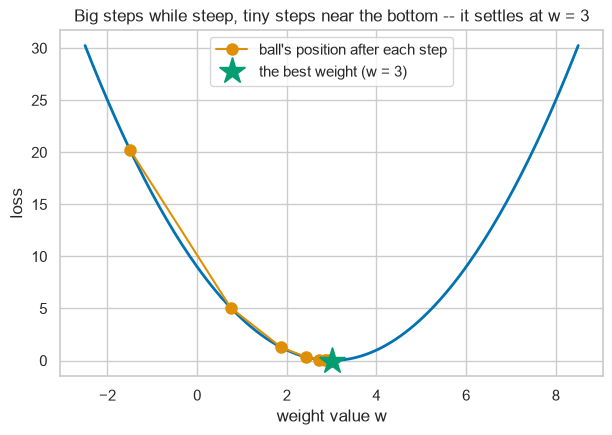

In [14]:
w = -1.5              # start far from the bottom (a bad initial weight)
learning_rate = 0.25
path = [w]            # remember every position so we can plot the journey

for step in range(8):                          # 8 steps of gradient descent
    slope = bowl_slope(w)                      # feel the slope under our feet
    w = w - learning_rate * slope              # THE update rule: step downhill
    path.append(w)                             # log the new position

print("path of w:", np.round(path, 3))         # np.round: round each value for display

fig, ax = plt.subplots(figsize=(7, 4.5))
w_axis = np.linspace(-2.5, 8.5, 200)
ax.plot(w_axis, bowl(w_axis), color=COLOR_MOON0, linewidth=2)   # the bowl

path = np.array(path)                          # list -> array so we can do math on it
ax.plot(path, bowl(path), "o-", color=COLOR_MOON1, markersize=8,
        label="ball's position after each step")
ax.plot(3, 0, "*", color=COLOR_ACCENT, markersize=20, label="the best weight (w = 3)")

ax.set_xlabel("weight value w")
ax.set_ylabel("loss")
ax.set_title("Big steps while steep, tiny steps near the bottom -- it settles at w = 3")
ax.legend()
plt.show()

Notice the steps shrink automatically: where the bowl is steep the slope is large (big step), near the bottom the slope approaches 0 (tiny step). Nobody told the ball to slow down — the slope did.

Now the classic failure: make the stride **too long**. With `learning_rate = 1.1`, every step leaps clear across the valley and lands *higher* than it started.

path of w: [ -1.5   8.4  -3.5  10.8  -6.3  14.2 -10.4  19.1 -16.3]


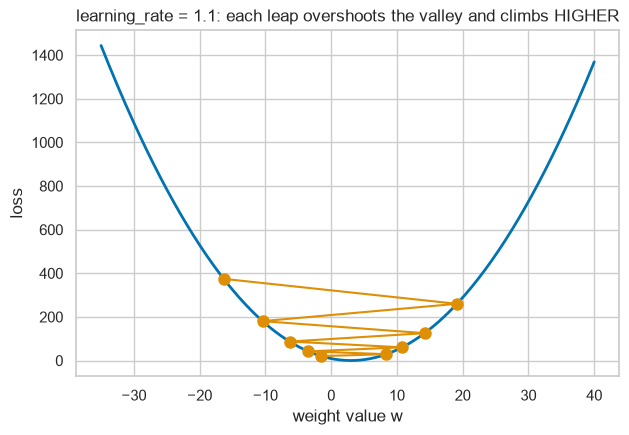

In [15]:
w = -1.5
too_big = 1.1                  # stride length way too long for this bowl
bad_path = [w]

for step in range(8):
    w = w - too_big * bowl_slope(w)   # same rule, oversized steps
    bad_path.append(w)

print("path of w:", np.round(bad_path, 1))   # watch it ping-pong AWAY from 3

fig, ax = plt.subplots(figsize=(7, 4.5))
w_axis = np.linspace(-35, 40, 300)
ax.plot(w_axis, bowl(w_axis), color=COLOR_MOON0, linewidth=2)
bad_path = np.array(bad_path)
ax.plot(bad_path, bowl(bad_path), "o-", color=COLOR_MOON1, markersize=8)
ax.set_xlabel("weight value w")
ax.set_ylabel("loss")
ax.set_title("learning_rate = 1.1: each leap overshoots the valley and climbs HIGHER")
plt.show()

## 8. Build the two-layer network

Everything is now on the table. The network:

- **Layer 1:** 2 inputs → 8 hidden neurons, `tanh` activation (the committee of 8 straight-line questions)
- **Layer 2:** 8 hidden answers → 1 output neuron, `sigmoid` activation (probability of "moon 1")

Instead of `w1, w2` per neuron we now keep whole **weight matrices**: column `j` of `W1` holds hidden neuron `j`'s personal `(w1, w2)`, so `X @ W1 + b1` computes all 8 weighted sums for all 400 points in one line — Module 01's "think in arrays" habit paying off.

We start the weights as **small random numbers**. Why not zeros? If every hidden neuron started identical, each would receive identical blame and stay identical forever — 8 clones of one neuron. Random starts break the tie (and small values keep tanh in its S-curve sweet spot rather than saturated flat).

In [16]:
rng = np.random.default_rng(42)   # a random-number generator with a fixed seed

n_hidden = 8   # committee size -- try changing this in the exercises

# rng.normal(mean, spread, size) draws random numbers from a bell curve.
W1 = rng.normal(0, 0.5, size=(2, n_hidden))   # shape: (2, 8) -- input-to-hidden weights
b1 = np.zeros((1, n_hidden))                  # shape: (1, 8) -- one bias per hidden neuron
W2 = rng.normal(0, 0.5, size=(n_hidden, 1))   # shape: (8, 1) -- hidden-to-output weights
b2 = np.zeros((1, 1))                         # shape: (1, 1) -- the output neuron's bias

# The labels y are shape (400,); reshape to a column so shapes line up with predictions.
Y = y.reshape(-1, 1).astype(float)            # shape: (400, 1) -- -1 means "figure out this dimension"

total = W1.size + b1.size + W2.size + b2.size   # .size counts the numbers in an array
print("weights to learn:", total)               # 16 + 8 + 8 + 1 = 33 knobs

weights to learn: 33


**The forward pass** — data flows left to right through the network, exactly like section 2's multiply-add-squash, done twice:

In [17]:
def forward(X, W1, b1, W2, b2):
    # Layer 1: every point through all 8 hidden neurons at once.
    Z1 = X @ W1 + b1        # shape: (400, 8) -- 8 weighted sums per point
    A1 = np.tanh(Z1)        # shape: (400, 8) -- bent by the activation ("A" = activated)
    # Layer 2: combine the committee's 8 answers into one probability.
    Z2 = A1 @ W2 + b2       # shape: (400, 1) -- one weighted sum per point
    A2 = sigmoid(Z2)        # shape: (400, 1) -- probability of "moon 1"
    return A1, A2           # we return A1 too -- the backward pass will need it

A1, A2 = forward(X, W1, b1, W2, b2)
print("first 3 predictions (untrained):")
print(np.round(A2[:3], 3))                      # random weights -> clueless ~0.5-ish guesses
print("loss before any training:", round(bce_loss(A2, Y), 4))

first 3 predictions (untrained):
[[0.527]
 [0.596]
 [0.682]]
loss before any training: 0.6632


**The backward pass (backpropagation)** — the loss is one number, but we have 33 knobs. Which knob moves, and by how much? Backprop answers by passing **blame** backward through the network:

1. At the output, the blame is beautifully simple: `prediction - truth`. Predicted 0.9 when the truth was 1? Blame is −0.1 (output should have been higher). Predicted 0.9 when the truth was 0? Blame +0.9 — big.
2. Each weight's slope is then *blame × what flowed through me*: a weight that carried a strong signal into a wrong answer takes a lot of the blame; a weight that carried nothing takes none.
3. The hidden layer's blame is the output blame passed backward through the same weights that carried the signal forward, dialed down where tanh was saturated (a neuron pinned at −1 or +1 barely responds, so nudging its weights barely helps — it gets little blame).

This "share of the blame" bookkeeping is the **chain rule** from calculus doing the accounting. The formulas below implement it; the *derivation* lives in the optional aside afterward and can be skipped entirely.

In [18]:
def backward(X, Y, A1, A2, W2):
    n = X.shape[0]                    # number of data points (400)

    # Step 1: blame at the output = prediction - truth  (divided by n: average blame).
    output_blame = (A2 - Y) / n                        # shape: (400, 1)

    # Step 2: slope for each layer-2 weight = blame x what flowed through it.
    # .T is transpose (flip rows/columns) so the shapes line up for @.
    dW2 = A1.T @ output_blame                          # shape: (8, 1) -- matches W2
    db2 = output_blame.sum(axis=0, keepdims=True)      # shape: (1, 1) -- matches b2
    # (keepdims=True keeps the result 2-D so it matches b2's shape.)

    # Step 3: pass blame backward to the hidden layer through W2,
    # dialing it down where tanh was saturated ((1 - A1**2) is tanh's slope:
    # near 1 when the neuron is responsive, near 0 when pinned at -1 or +1).
    hidden_blame = (output_blame @ W2.T) * (1 - A1 ** 2)   # shape: (400, 8)

    # Step 4: same blame-x-input recipe for the layer-1 weights.
    dW1 = X.T @ hidden_blame                           # shape: (2, 8) -- matches W1
    db1 = hidden_blame.sum(axis=0, keepdims=True)      # shape: (1, 8) -- matches b1

    return dW1, db1, dW2, db2

def update(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    # The bowl's update rule, applied to every knob at once:
    # new_weight = old_weight - learning_rate * slope
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

### Optional aside: where the blame formulas come from *(skip freely)*

This box is for the curious only — nothing later depends on it.

The chain rule from calculus says: if the loss depends on the output, and the output depends on a weight, then

> (how loss changes per unit of weight) = (how loss changes per unit of output) × (how output changes per unit of weight).

Blame literally *multiplies along the path* from the loss back to each weight. Three facts make our particular formulas drop out:

1. **Sigmoid + cross-entropy cancel.** The sigmoid's slope and the cross-entropy's slope are near-perfect reciprocals, and their product collapses to just `prediction - truth`. (This tidy cancellation is exactly why we chose cross-entropy in section 6.)
2. **A weighted sum's slope with respect to a weight is its input.** If `z = w * a + ...`, nudging `w` by a hair changes `z` by `a` hairs — hence every "blame × what flowed through me" line, which in matrix form becomes the transposes: `A1.T @ output_blame` and `X.T @ hidden_blame`.
3. **tanh's slope is `1 - tanh**2`.** Steepest (slope 1) at the center, flat (slope 0) when saturated — hence the `(1 - A1**2)` dial-down.

Chain those three along every input→hidden→output path and you get precisely the `backward` function above. In Module 10, PyTorch's *autograd* will do this bookkeeping for us automatically — now you know what it's automating.

## 9. Train it: 2000 trips down the hill

One **epoch** = one full pass over all 400 points: forward (predict), loss (grade), backward (assign blame), update (step downhill). We repeat 2000 times, log the loss, and stash snapshots of the weights at a few epochs so we can replay the learning as a filmstrip afterward.

(2000 epochs of this tiny network takes about a second — no need to subsample anything.)

In [19]:
learning_rate = 1.0
n_epochs = 2000
snapshot_epochs = [0, 100, 500, 2000]   # moments to photograph for the filmstrip

losses = []       # loss after every epoch, for the learning curve
snapshots = {}    # dictionary: epoch number -> copy of all four weight arrays

for epoch in range(n_epochs + 1):        # +1 so we also photograph the final state
    A1, A2 = forward(X, W1, b1, W2, b2)         # predict
    current_loss = bce_loss(A2, Y)              # grade
    losses.append(current_loss)

    if epoch in snapshot_epochs:                # 'in' asks: is epoch in that list?
        # .copy() stores an independent copy -- otherwise the snapshot would keep
        # changing as training continues (arrays are shared by reference).
        snapshots[epoch] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

    if epoch == n_epochs:
        break                                   # photographed the end -- don't step again

    dW1, db1, dW2, db2 = backward(X, Y, A1, A2, W2)                        # blame
    W1, b1, W2, b2 = update(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)  # step

    if epoch % 400 == 0:                        # % is remainder: True every 400 epochs
        print("epoch", epoch, "-> loss", round(current_loss, 4))

print("final loss:", round(losses[-1], 4))      # losses[-1] = last entry in the list

epoch 0 -> loss 0.6632


epoch 400 -> loss 0.171
epoch 800 -> loss 0.1586
epoch 1200 -> loss 0.1558
epoch 1600 -> loss 0.1537
final loss: 0.1501


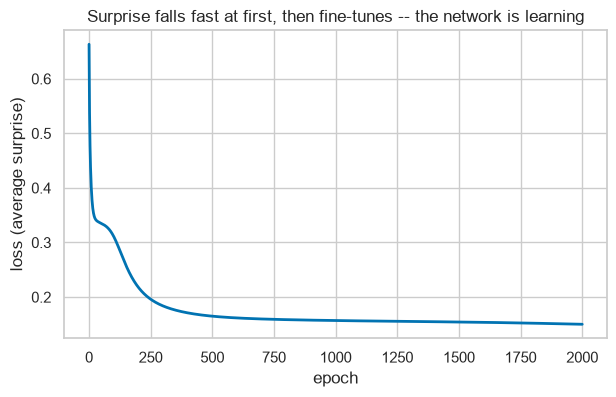

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color=COLOR_MOON0, linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("loss (average surprise)")
ax.set_title("Surprise falls fast at first, then fine-tunes -- the network is learning")
plt.show()

## 10. The filmstrip: watch the boundary curve itself around the moons

Now the payoff. Using the weight snapshots, we redraw the decision boundary at epochs 0, 100, 500 and 2000 with the same background-coloring trick from section 4 — and watch a straight-ish newborn boundary *bend itself around the data*.

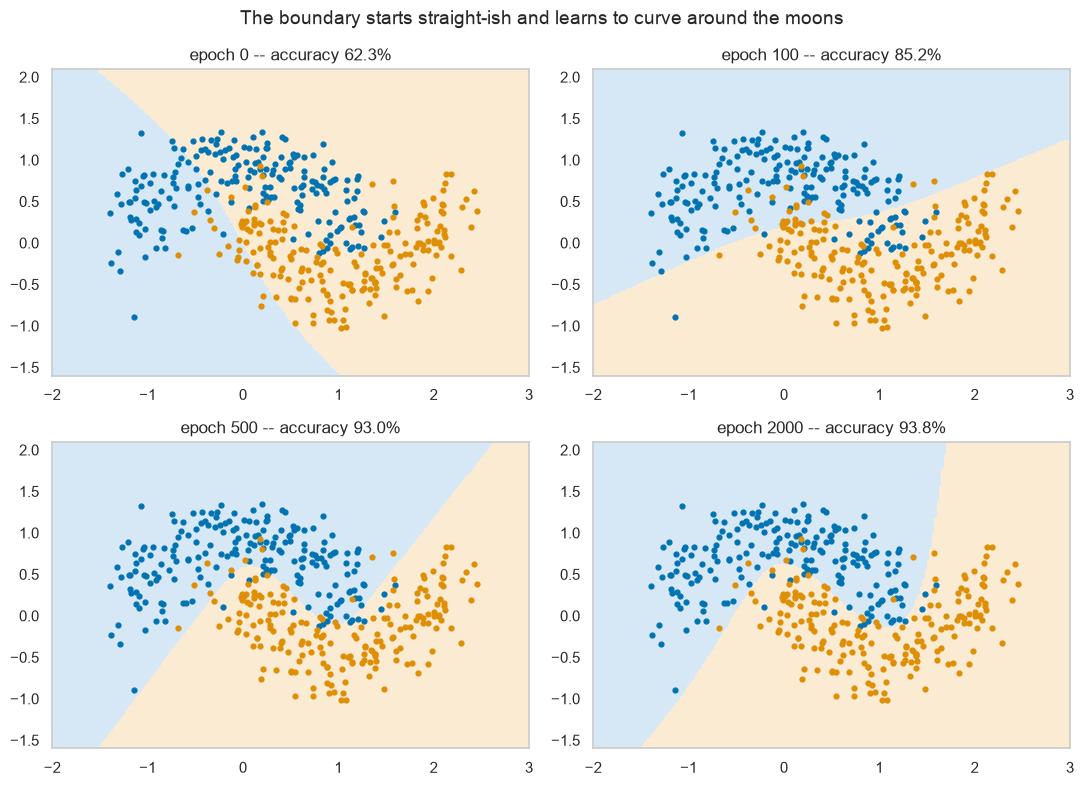

In [21]:
def network_predictions(points, W1, b1, W2, b2):
    # Run any set of points through the network and return hard 0/1 answers.
    A1, A2 = forward(points, W1, b1, W2, b2)
    # A2 > 0.5 gives True/False; .astype(int) turns that into 1/0.
    return (A2 > 0.5).astype(int)

def accuracy_of(W1, b1, W2, b2):
    predictions = network_predictions(X, W1, b1, W2, b2)   # shape: (400, 1)
    # predictions == Y gives True/False per point; the mean of True/False
    # values is the fraction correct (True counts as 1).
    return (predictions == Y).mean()

# 2x2 grid of panels; axes.ravel() flattens it to a list of 4 (same ravel as before).
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
panels = axes.ravel()

panel_number = 0
for epoch in snapshot_epochs:
    ax = panels[panel_number]
    sW1, sb1, sW2, sb2 = snapshots[epoch]       # unpack that epoch's saved weights

    # Same recipe as section 4: classify every grid point, color the background.
    grid_answers = network_predictions(grid_points, sW1, sb1, sW2, sb2)
    grid_answers = grid_answers.reshape(grid_x.shape)          # shape: (200, 200)
    ax.contourf(grid_x, grid_y, grid_answers, levels=[-0.5, 0.5, 1.5],
                colors=["#D6E8F5", "#FCEBD3"])
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color=COLOR_MOON0, s=12)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color=COLOR_MOON1, s=12)

    acc_percent = round(accuracy_of(sW1, sb1, sW2, sb2) * 100, 1)
    ax.set_title("epoch " + str(epoch) + " -- accuracy " + str(acc_percent) + "%")
    panel_number = panel_number + 1

fig.suptitle("The boundary starts straight-ish and learns to curve around the moons",
             fontsize=14)
plt.tight_layout()
plt.show()

Epoch 0 is the random newborn: a nearly straight, nearly useless boundary. By epoch 100 it has found the general split; by 500 it is visibly *curving into the gap between the crescents*; by 2000 it hugs them. Nobody programmed a curve — 33 numbers walked downhill on the surprise landscape, and the curve emerged.

## 11. Final score: the committee vs the ruler

In [22]:
network_accuracy = accuracy_of(W1, b1, W2, b2)    # the fully trained network

print("straight line (logistic regression):", round(line_accuracy * 100, 1), "%")
print("2-layer network (33 weights):       ", round(network_accuracy * 100, 1), "%")
print()
print("With noise=0.25 the moons overlap a little, so even a perfect")
print("boundary can't score 100% -- some points sit in enemy territory.")

straight line (logistic regression): 84.2 %
2-layer network (33 weights):        93.8 %

With noise=0.25 the moons overlap a little, so even a perfect
boundary can't score 100% -- some points sit in enemy territory.


## 12. Learning-rate experiments: crawl, cruise, chaos

One dial controls the whole descent: the stride length. Let's retrain the same network three times from the *same* random start, changing only the learning rate — 0.01, 1.0, and 10.

In [23]:
def train_network(chosen_learning_rate, n_epochs):
    # Re-create the SAME starting weights every time (same seed = fair comparison).
    rng = np.random.default_rng(42)
    tW1 = rng.normal(0, 0.5, size=(2, n_hidden))   # shape: (2, 8)
    tb1 = np.zeros((1, n_hidden))                  # shape: (1, 8)
    tW2 = rng.normal(0, 0.5, size=(n_hidden, 1))   # shape: (8, 1)
    tb2 = np.zeros((1, 1))                         # shape: (1, 1)

    loss_history = []
    for epoch in range(n_epochs):
        tA1, tA2 = forward(X, tW1, tb1, tW2, tb2)
        loss_history.append(bce_loss(tA2, Y))
        dW1, db1, dW2, db2 = backward(X, Y, tA1, tA2, tW2)
        tW1, tb1, tW2, tb2 = update(tW1, tb1, tW2, tb2,
                                    dW1, db1, dW2, db2, chosen_learning_rate)
    final_acc = (network_predictions(X, tW1, tb1, tW2, tb2) == Y).mean()
    return loss_history, final_acc

losses_small, acc_small = train_network(0.01, 2000)
losses_good, acc_good = train_network(1.0, 2000)
losses_huge, acc_huge = train_network(10.0, 2000)

print("lr = 0.01 -> final accuracy", round(acc_small * 100, 1), "%")
print("lr = 1.0  -> final accuracy", round(acc_good * 100, 1), "%")
print("lr = 10   -> final accuracy", round(acc_huge * 100, 1), "%")

lr = 0.01 -> final accuracy 83.8 %
lr = 1.0  -> final accuracy 93.8 %
lr = 10   -> final accuracy 94.0 %


lr = 10: loss went UP on 996 of 2000 steps
lr = 10: worst loss reached: 7.4


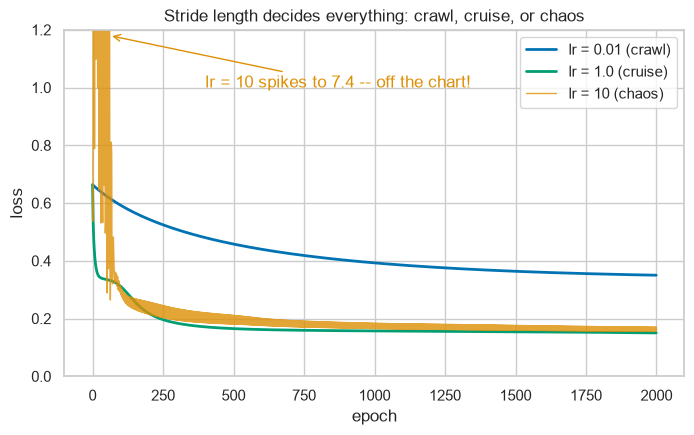

In [24]:
# How chaotic was each run?  Count the epochs where the loss went UP
# (a healthy descent should almost always go DOWN).
uphill_steps = 0
for i in range(1, len(losses_huge)):
    if losses_huge[i] > losses_huge[i - 1]:    # compare each loss to the one before
        uphill_steps = uphill_steps + 1
print("lr = 10: loss went UP on", uphill_steps, "of 2000 steps")
print("lr = 10: worst loss reached:", round(max(losses_huge), 1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses_small, color=COLOR_MOON0, linewidth=2, label="lr = 0.01 (crawl)")
ax.plot(losses_good, color=COLOR_ACCENT, linewidth=2, label="lr = 1.0 (cruise)")
ax.plot(losses_huge, color=COLOR_MOON1, linewidth=1, alpha=0.8, label="lr = 10 (chaos)")

ax.set_ylim(0, 1.2)   # zoom in -- the chaos curve spikes far above this window
ax.annotate("lr = 10 spikes to " + str(round(max(losses_huge), 1)) + " -- off the chart!",
            xy=(60, 1.18), xytext=(400, 1.0), color=COLOR_MOON1,
            arrowprops=dict(arrowstyle="->", color=COLOR_MOON1))
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Stride length decides everything: crawl, cruise, or chaos")
ax.legend()
plt.show()

Read the three curves:

- **0.01 (crawl):** heading the right way, but after 2000 epochs it's still far up the hillside — it would need tens of thousands of epochs.
- **1.0 (cruise):** drops fast, settles low. A good stride for this bowl.
- **10 (chaos):** ricochets violently — the loss went *up* on roughly half of all steps, spiking to several times its starting value. This run happened to stumble into the valley anyway; often (as with our 1-D bowl at `learning_rate = 1.1`) it never does. You can't count on luck.

There is no universal best learning rate — practitioners try a few powers of ten and watch the loss curve, exactly as you just did.

---

### Where this goes next

You have now built, by hand, every part that PyTorch automates in Module 10: `forward` (it keeps), `bce_loss` (built in), `backward` (autograd derives it for you), `update` (the optimizer). The thermocycler is about to arrive — but you know what PCR does.

> **A neural network is a committee of tiny straight-line questions, bent by activation functions and tuned by blame.** Everything in deep learning — up to GPT — is this loop, scaled up.